<style>
    img {
        display: block;
        margin-left: auto;
        margin-right: auto;
    }
</style>

<div style="background-color:#000047; padding: 30px; border-radius: 10px; color: white; text-align: center;">
    <img src='Figures/alinco_white_text.png' style="height: 100px; margin-bottom: 10px;"/>
    <h1>Módulo 3: Aprendizaje por refuerzo con Gym</h1>
    <h3>Aprendizaje Automático Avanzado 2026</h3>
</div>

En esta libreta de jupyter notebook utilizaremos la librería **Gym** para explorar, paso a paso, la interfaz de un entorno de aprendizaje por refuerzo.

En el aprendizaje supervisado, el modelo aprende a partir de ejemplos que incluyen una respuesta conocida. En el aprendizaje por refuerzo no existe una etiqueta correcta para cada entrada. En su lugar, un **agente** interactúa con un entorno, toma acciones y recibe recompensas que orientan su comportamiento.

Este enfoque resulta especialmente útil cuando las decisiones están conectadas en el tiempo. Por ejemplo, para conducir un vehículo no basta con detectar un semáforo: también es necesario considerar la velocidad, la trayectoria, las curvas, los peatones, la iluminación y las consecuencias de cada decisión.

El aprendizaje por refuerzo permite modelar este tipo de problemas como una secuencia de decisiones:

1. El agente observa el estado actual del entorno.
2. El agente selecciona una acción.
3. El entorno cambia y devuelve una recompensa.
4. El agente utiliza esa experiencia para mejorar sus decisiones futuras.

La recompensa no debe entenderse únicamente como un premio inmediato. Su propósito es orientar al agente hacia un objetivo global, incluso cuando para alcanzarlo deba aceptar resultados poco favorables en algunos pasos intermedios.

En la primera parte repasaremos los conceptos esenciales de RL. Después utilizaremos el entorno `Maze` para estudiar la interfaz de Gym y ejecutar un episodio con una política aleatoria.

## 1. Componentes del aprendizaje por refuerzo

El aprendizaje por refuerzo se construye alrededor de la interacción entre un agente y un entorno:

- **Agente**: modelo o sistema que aprende a tomar decisiones.
- **Entorno**: sistema en el que el agente interactúa y que contiene las reglas, limitaciones y transiciones posibles.
- **Estado ($S_t$)**: descripción de la situación actual del entorno.
- **Acción ($A_t$)**: decisión que el agente puede ejecutar en el estado actual.
- **Recompensa ($R_{t+1}$)**: seÃ±al numérica que evalúa el resultado inmediato de la acción.

El ciclo de interacción puede expresarse como:

$$S_t \xrightarrow{A_t} S_{t+1}, R_{t+1}$$

El agente observa $S_t$, elige $A_t$ y el entorno responde con un nuevo estado $S_{t+1}$ y una recompensa $R_{t+1}$. Este ciclo se repite hasta que termina el episodio.

<img src="Figures/mdp_diagram.svg" alt="Interacción entre agente y entorno" style="display: block; margin: 0 auto;" width="450">

La secuencia de estados, acciones y recompensas se interpreta como un **Proceso de Decisión de Markov**. En este marco, el estado actual resume la información necesaria para decidir qué acción tomar a continuación.

En cada paso, el agente recibe el estado actual, elige una acción y modifica el entorno. Como consecuencia, el entorno devuelve un nuevo estado y una recompensa. Una recompensa positiva hace más probable que el agente conserve un comportamiento similar; una recompensa negativa indica que conviene revisarlo.

Esta interacción no busca maximizar únicamente la recompensa del paso actual. El agente debe aprender una política que produzca un buen resultado acumulado a lo largo del episodio.

En este notebook utilizaremos la interfaz de Gym para observar directamente este ciclo mediante los métodos `reset`, `render`, `step` y `close`.

## 2. Q-Learning: idea general

**Q-Learning** es un algoritmo que aprende el valor de ejecutar una acción concreta en un estado determinado. Ese valor se representa mediante $Q(s,a)$:

> $Q(s,a)$ estima quétan conveniente es tomar la acción $a$ cuando el agente se encuentra en el estado $s$.

Para cada estado, el agente puede elegir entre varias acciones. Durante el aprendizaje, la estimación se actualiza con base en la recompensa inmediata y en el valor esperado del estado siguiente.

En términos prácticos, la Q-Table funciona como una guía de decisión. El agente puede explotar la acción con mayor valor o explorar otras acciones para descubrir alternativas potencialmente mejores.

La ecuación de actualización utiliza dos hiperparámetros:

- **Tasa de aprendizaje ($\alpha$)**: controla cuánto influye la nueva experiencia sobre el valor almacenado.
- **Factor de descuento ($\gamma$)**: controla cuánto peso se asigna a las recompensas futuras frente a la recompensa inmediata.

En la siguiente sección se muestra una forma habitual de actualizar la función Q.

La actualización de Q-Learning puede escribirse como:

$$\hat{Q}(s,a) = Q(s,a) + \alpha \left[R + \gamma \max_{a'} Q(s',a') - Q(s,a)\right]$$

Donde:

- $Q(s,a)$ es el valor estimado actualmente.
- $\alpha$ es la tasa de aprendizaje.
- $R$ es la recompensa obtenida después de ejecutar la acción.
- $\gamma$ es el factor de descuento.
- $\max_{a'} Q(s',a')$ es el mejor valor estimado en el estado siguiente.

La expresión combina lo que el agente ya creía con la nueva información obtenida. Una tasa de aprendizaje alta permite cambiar rápidamente las estimaciones; un factor de descuento alto hace que el agente valore más las consecuencias a largo plazo.

## 3. Conociendo la interfaz de Gymnasium

Gymnasium proporciona una interfaz común para construir y utilizar entornos de aprendizaje por refuerzo. Entre sus ejemplos se encuentran tareas de control clásico, videojuegos y problemas de control continuo.

En este notebook trabajaremos con el entorno `Maze` y utilizaremos cinco operaciones principales:

1. Crear el entorno.
2. Reiniciarlo con `reset`.
3. Visualizarlo con `render`.
4. Ejecutar una acción con `step`.
5. Liberar sus recursos con `close`.

La API actual de Gymnasium devuelve cinco valores al llamar a `step`: el siguiente estado, la recompensa, los indicadores `terminated` y `truncated`, y un diccionario con información adicional.

In [ ]:
#!pip install gymnasium

In [1]:
import gymnasium as gym
import numpy as np
from IPython import display
from matplotlib import pyplot as plt

from envs import Maze
#from envs import Maze2

### 3.1. Crear el entorno: `Maze()`

La clase `Maze`, importada desde `envs`, representa el entorno que utilizaremos. Al crear una instancia se inicializan sus estados, acciones, recompensas y reglas de transición.

En Gym, los entornos suelen crearse mediante `gym.make('nombre-del-entorno')`. En este ejemplo usamos directamente `Maze()` porque es un entorno definido localmente para el curso.

In [2]:
env = Maze()

### 3.2. Reiniciar el entorno: `env.reset()`

`reset()` devuelve el entorno a su estado inicial y prepara un nuevo episodio. El agente debe observar este estado antes de elegir su primera acción.

La celda siguiente guarda el estado inicial en `initial_state` y lo muestra.

In [3]:
initial_state, _ = env.reset()
print(f"The new episode will start in state: {initial_state}")

The new episode will start in state: (0, 0)


### 3.3. Visualizar el entorno: `env.render()`

`render()` genera una representación visual del estado actual como un arreglo de NumPy. Después podemos mostrar ese arreglo con Matplotlib.

La visualización es útil para comprobar que la posición del agente y las transiciones del entorno coinciden con lo esperado.

In [4]:
# Gymnasium renders the current state directly as an RGB array.

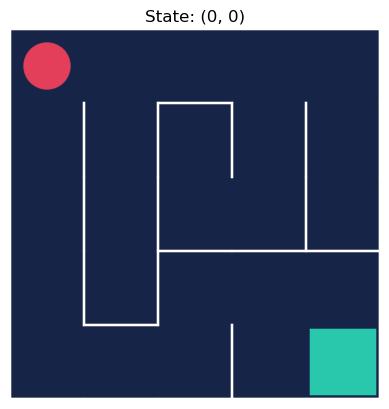

In [5]:
frame = env.render()
plt.axis('off')
plt.title(f"State: {initial_state}")
plt.imshow(frame)

La versión actual de Gymnasium devuelve cinco valores al llamar a `step`: el siguiente estado, la recompensa, los indicadores `terminated` y `truncated`, y un diccionario con información adicional.

In [6]:
action = 2
next_state, reward, terminated, truncated, info = env.step(action)
finished = terminated or truncated
print(f"After moving down 1 row, the agent is in state: {next_state}")
print(f"After moving down 1 row, we got a reward of: {reward}")
print("After moving down 1 row, the task is", "" if finished else "not", "finished")

After moving down 1 row, the agent is in state: (1, 0)
After moving down 1 row, we got a reward of: -1.0
After moving down 1 row, the task is not finished


#### Visualizar el nuevo estado

Después de ejecutar `step`, volvemos a renderizar el entorno para observar cómo cambió su estado.

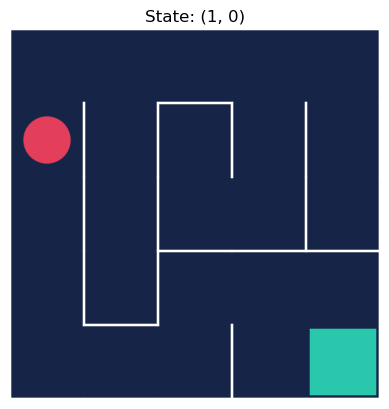

In [7]:
frame = env.render()
plt.axis('off')
plt.title(f"State: {next_state}")
plt.imshow(frame)

### 3.5. Cerrar el entorno: `env.close()`

`close()` finaliza el entorno y libera los recursos asociados, especialmente los relacionados con la visualización.

In [8]:
env.close()

### 3.4. Ejecutar una acción: `env.step(action)`

`step(action)` aplica una acción al entorno y devuelve cinco valores:

1. `next_state`: estado después de ejecutar la acción.
2. `reward`: recompensa obtenida.
3. `terminated`: indica si la tarea terminó naturalmente.
4. `truncated`: indica si el episodio fue truncado por un límite externo.
5. `info`: diccionario con información adicional del entorno.

En Gymnasium, el episodio termina cuando `terminated` o `truncated` es `True`.

###### Creando el entorno

In [9]:
env = Maze()

### 4.1. Estados y espacio de estados

Cada estado se representa mediante una pareja de enteros $(row, column)$, que indica la fila y la columna ocupadas por el agente:

$$s = (row, column), \qquad row,column \in \{0,1,2,3,4\}$$

El espacio de estados contiene las 25 combinaciones posibles de filas y columnas:

$$|\mathcal{S}| = 5 \times 5 = 25$$

La propiedad `env.observation_space` describe este espacio. En este entorno es `MultiDiscrete([5, 5])`, porque el estado tiene dos componentes y cada componente puede tomar cinco valores.

In [10]:
initial_state, _ = env.reset()
print(f"For example, the initial state is: {initial_state}")
print(f"The space state is of type: {env.observation_space}")

For example, the initial state is: (0, 0)
The space state is of type: MultiDiscrete([5 5])


### 4.2. Acciones y espacio de acciones

El agente puede ejecutar cuatro acciones, representadas por enteros:

| Código | Acción |
|---:|---|
| 0 | Arriba |
| 1 | Derecha |
| 2 | Abajo |
| 3 | Izquierda |

El espacio de acciones se encuentra en `env.action_space` y es `Discrete(4)`: contiene cuatro opciones posibles. Para ejecutar una acción, se pasa su código al método `env.step(action)`.

In [11]:
print(f"An example of a valid action is: {env.action_space.sample()}")
print(f"The action state is of type: {env.action_space}")

An example of a valid action is: 3
The action state is of type: Discrete(4)


### 4.3. Trayectorias y episodios

Una **trayectoria** es una secuencia de transiciones que registra cómo el agente pasa de un estado a otro:

$$\tau = S_0, A_0, R_1, S_1, A_1, \dots, R_N, S_N$$

El siguiente ejemplo genera una trayectoria de tres movimientos. En cada paso se guarda el estado actual, la acción, la recompensa, el indicador de finalización y el siguiente estado.

In [12]:
env = Maze()
state, _ = env.reset()
trajectory = []
for _ in range(3):
    action = env.action_space.sample()
    next_state, reward, terminated, truncated, extra_info = env.step(action)
    done = terminated or truncated
    trajectory.append([state, action, reward, done, next_state])
    state = next_state
env.close()

print(f"first trajectory:\n{trajectory}")

first trajectory:
[[(0, 0), np.int64(0), -1.0, False, (0, 0)], [(0, 0), np.int64(3), -1.0, False, (0, 0)], [(0, 0), np.int64(2), -1.0, False, (1, 0)]]


Un **episodio** es una trayectoria completa: comienza en el estado inicial y termina cuando el entorno alcanza un estado terminal.

$$\tau = S_0, A_0, R_1, S_1, A_1, \dots, R_T, S_T$$

Aquí, $T$ representa el último paso del episodio. El siguiente código genera un episodio completo mediante acciones aleatorias.

In [13]:
env = Maze()
state, _ = env.reset()
episode = []
done = False
while not done:
    action = env.action_space.sample()
    next_state, reward, terminated, truncated, extra_info = env.step(action)
    done = terminated or truncated
    episode.append([state, action, reward, done, next_state])
    state = next_state
env.close()

print(f"first episode:\n{episode}")

first episode:
[[(0, 0), np.int64(0), -1.0, False, (0, 0)], [(0, 0), np.int64(0), -1.0, False, (0, 0)], [(0, 0), np.int64(1), -1.0, False, (0, 1)], [(0, 1), np.int64(0), -1.0, False, (0, 1)], [(0, 1), np.int64(3), -1.0, False, (0, 0)], [(0, 0), np.int64(0), -1.0, False, (0, 0)], [(0, 0), np.int64(0), -1.0, False, (0, 0)], [(0, 0), np.int64(1), -1.0, False, (0, 1)], [(0, 1), np.int64(1), -1.0, False, (0, 2)], [(0, 2), np.int64(3), -1.0, False, (0, 1)], [(0, 1), np.int64(3), -1.0, False, (0, 0)], [(0, 0), np.int64(3), -1.0, False, (0, 0)], [(0, 0), np.int64(0), -1.0, False, (0, 0)], [(0, 0), np.int64(0), -1.0, False, (0, 0)], [(0, 0), np.int64(1), -1.0, False, (0, 1)], [(0, 1), np.int64(1), -1.0, False, (0, 2)], [(0, 2), np.int64(0), -1.0, False, (0, 2)], [(0, 2), np.int64(3), -1.0, False, (0, 1)], [(0, 1), np.int64(3), -1.0, False, (0, 0)], [(0, 0), np.int64(0), -1.0, False, (0, 0)], [(0, 0), np.int64(0), -1.0, False, (0, 0)], [(0, 0), np.int64(1), -1.0, False, (0, 1)], [(0, 1), np.int6

### 4.4. Recompensas y retorno

Una recompensa es la seÃ±al numérica que el entorno devuelve después de que el agente ejecuta una acción:

$$R_{t+1} = r(S_t, A_t)$$

En este laberinto, la recompensa es $-1$ por cada paso. Por tanto, una ruta más corta produce un retorno menos negativo.

El **retorno descontado** desde el instante $t$ es la suma de las recompensas futuras, ponderadas por el factor de descuento $\gamma$:

$$G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \dots$$

A continuación observaremos una recompensa individual y después calcularemos $G_0$ para un episodio completo.

In [14]:
env = Maze()
state, _ = env.reset()
action = env.action_space.sample()
_, reward, _, _, _ = env.step(action)
print(f"We achieved a reward of {reward} by taking action {action} in state {state}")

We achieved a reward of -1.0 by taking action 2 in state (0, 0)


Para calcular el retorno inicial $G_0$, acumularemos todas las recompensas del episodio usando $\gamma = 0.99$.

Un valor de $\gamma$ cercano a 1 da más importancia a las recompensas futuras. Como aquí cada movimiento recibe $-1$, el retorno permite comparar cuánto tardó el agente en encontrar la salida: cuanto más corto sea el episodio, menos negativo será $G_0$.

In [15]:
env = Maze()
state, _ = env.reset()
done = False
gamma = 0.99
G_0 = 0
t = 0
while not done:
    action = env.action_space.sample()
    _, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    G_0 += gamma ** t * reward
    t += 1
env.close()

print(
    f"""It took us {t} moves to find the exit, 
    and each reward r(s,a)=-1, so the return amounts to {G_0}""")

It took us 748 moves to find the exit, 
    and each reward r(s,a)=-1, so the return amounts to -99.9456592586585


### 4.5. Política

Una política $\pi$ asigna una probabilidad a cada acción posible dado un estado:

$$\pi(a \mid s) = P(A_t = a \mid S_t = s)$$

En la práctica, representaremos la política como una función que recibe un estado y devuelve un arreglo con las probabilidades de las cuatro acciones. Por ejemplo, `[0.5, 0.3, 0.1, 0.1]` indica que las acciones 0, 1, 2 y 3 tienen probabilidades del 50 %, 30 %, 10 % y 10 %, respectivamente.

En este ejemplo construiremos una política aleatoria uniforme: cada acción tendrá la misma probabilidad de ser seleccionada.

In [16]:
def random_policy(state):
    return np.array([0.25] * 4)

## 5. Ejecutar un episodio con una polÃ­tica aleatoria

Finalmente, reiniciaremos el entorno, calcularemos las probabilidades de la política uniforme y ejecutaremos acciones hasta alcanzar la salida.

Durante la ejecución se actualizará la imagen del laberinto después de cada acción. Como las acciones son aleatorias, la longitud del episodio y la ruta pueden cambiar entre ejecuciones.

### 5.1. Crear y reiniciar el entorno

Comenzamos un nuevo episodio creando el entorno y llamando a `reset()` para obtener el estado inicial.

In [17]:
env = Maze()
state, _ = env.reset()

### 5.2. Obtener las probabilidades $\pi(a \mid s)$

La función `random_policy` devuelve una probabilidad de `0.25` para cada una de las cuatro acciones. La gráfica permite comprobar que la polÃ­tica es uniforme.

In [18]:
action_probabilities = random_policy(state)

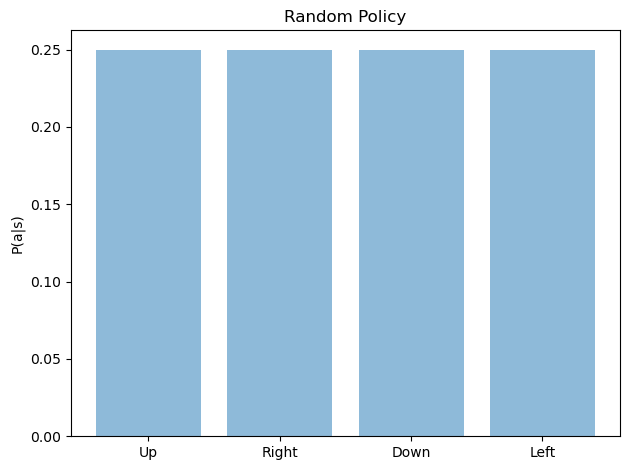

In [19]:
objects = ('Up', 'Right', 'Down', 'Left')
y_pos = np.arange(len(objects))

plt.bar(y_pos, action_probabilities, alpha=0.5)
plt.xticks(y_pos, objects)
plt.ylabel('P(a|s)')
plt.title('Random Policy')
plt.tight_layout()

plt.show()

### 5.3. Ejecutar el episodio

En cada iteración se selecciona una acción según las probabilidades de la polÃ­tica, se ejecuta con `env.step(action)` y se actualiza la visualización. El ciclo termina cuando `done` es `True`.

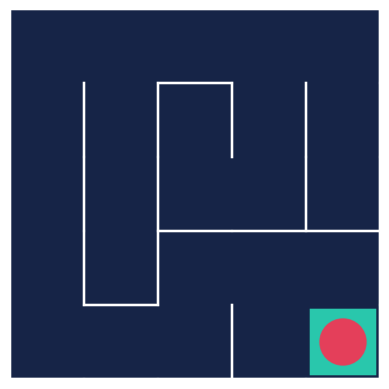

In [20]:
_, _ = env.reset()
done = False
img = plt.imshow(env.render())
while not done:
    action = np.random.choice(range(4), 1, p=action_probabilities).item()
    _, _, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    img.set_data(env.render())
    plt.axis('off')
    display.display(plt.gcf())
    display.clear_output(wait=True)
env.close()